In [1]:
import datetime
import os
import pickle
import random
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping
from ignite.handlers.param_scheduler import create_lr_scheduler_with_warmup
from ignite.metrics import Accuracy, Loss
from ignite.utils import convert_tensor
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau
from torch.utils.data import DataLoader, Subset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from clinic_datasets import CleanClinicDataset
from metrics import SklearnClassificationReport
from ignite.metrics.confusion_matrix import ConfusionMatrix
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utils import *
from model import BertGAT, BertGCN
import torch.utils.data as Data
import dgl

Using backend: pytorch


In [3]:
MODELPATH = "deepset/gbert-base"
LEARNINGRATE = 5e-5
NEPOCHS = 50
BATCHSIZE = 8
ACCUSTEPS = 8

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

tokenizer = AutoTokenizer.from_pretrained(MODELPATH)
SAVENAME = Path(MODELPATH).stem

dataset_file = Path("data") / "medindcls_bert.json"
if not dataset_file.exists():
    print("Creating dataset")
    dataset = CleanClinicDataset(tokenizer=tokenizer, clean=False)
    with open(dataset_file, "wb") as f:
        print(f"Saving dataset under {dataset_file}")
        pickle.dump(dataset, f)
else:
    print(f"Loading dataset from: {dataset_file}")
    with open(dataset_file, "rb") as f:
        dataset = pickle.load(f)

SAVEPATH = Path(f"models/finetuned/{SAVENAME}_{dataset}_best.pt")

model = AutoModelForSequenceClassification.from_pretrained(MODELPATH, num_labels=len(dataset.LE.classes_))

idx = np.arange(len(dataset))
random.shuffle(idx)

_, _, test_idx = (
    idx[: int(len(idx) * 0.7)],
    idx[int(len(idx) * 0.7) : int(len(idx) * 0.8)],
    idx[int(len(idx) * 0.8) :],
)

test_dataset = Subset(dataset, test_idx)

test_loader = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), LEARNINGRATE)
criterion = torch.nn.CrossEntropyLoss()

Loading dataset from: data/medindcls_bert.json


Some weights of the model checkpoint at deepset/gbert-base were not used when initializing BertForSequenceClassification: ['cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint a

In [4]:
def eval_step(engine, batch):
    global model
    with torch.no_grad():
        model.eval()
        x, y = batch["input_ids"], batch["labels"]
        x, y = (convert_tensor(x, torch.device("cpu")), convert_tensor(y, torch.device("cpu")))
        y_pred = model(x).logits
        return y_pred, y

test_evaluator = Engine(eval_step)

metrics = {
    "accuracy": Accuracy(),
    "nll": Loss(criterion),
    "cr": SklearnClassificationReport(
        target_names=[dataset.LE.classes_[x] for x in np.unique(np.array(dataset.labels))]
    ),
    "cm": ConfusionMatrix(num_classes=len(np.unique(np.array(dataset.labels))))
}

for n, f in metrics.items():
    f.attach(test_evaluator, n)

In [5]:
print(f"Loading best gcn model from {SAVEPATH} saved on {datetime.datetime.fromtimestamp(SAVEPATH.stat().st_ctime)}")
ckpt = torch.load(SAVEPATH, map_location="cpu")
model.bert.load_state_dict(ckpt["bert_model"])
model.classifier.load_state_dict(ckpt["classifier"])
test_evaluator.run(test_loader)
metrics = test_evaluator.state.metrics
print(
    f"Test Results - Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['nll']:.2f}"
)

Loading best gcn model from models/finetuned/gbert-base_med_indication_all_RF_diag_best.pt saved on 2022-10-27 15:55:48
Test Results - Avg accuracy: 0.91 Avg loss: 0.36


/home/pwiesenbach/anaconda3/envs/BertGCN/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1985: UserWarning:

labels size, 11, does not match size of target_names, 12



<AxesSubplot:>

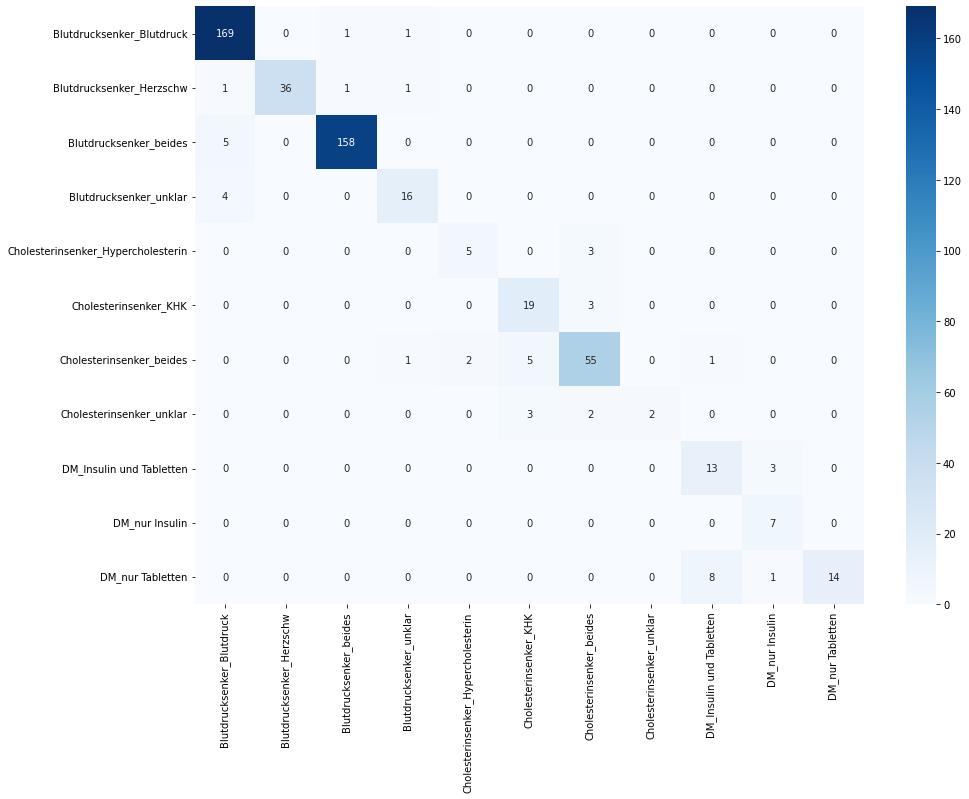

In [6]:
df_cm = pd.DataFrame(metrics["cm"].cpu().numpy(), index = dataset.LE.classes_,
                  columns = dataset.LE.classes_)
df_cm = df_cm.loc[df_cm.index != "Blutdrucksenker_Hypercholesterin", df_cm.columns != "Blutdrucksenker_Hypercholesterin"]
plt.figure(figsize = (15,11))
sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='')

In [73]:
MODELPATH = "deepset/gbert-base"
SAVEPATH = f"{Path(MODELPATH).stem}"
GCNPATH = Path(f"models/gcn/{SAVEPATH}_{dataset}_best.pt")
DATASET = "med_indication_all_RF_diag"
BERTLR = 5e-5
GCNLR = 3e-5

device = "cpu"

adj, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, _, _ = load_corpus(DATASET)

nb_node = features.shape[0]
nb_train, nb_val, nb_test = train_mask.sum(), val_mask.sum(), test_mask.sum()
nb_word = nb_node - nb_train - nb_val - nb_test
nb_class = y_train.shape[1]

# if gcn_model == "gcn":
model = BertGCN(
    nb_class=nb_class,
    pretrained_model="deepset/gbert-base",
    mix_factor=0.4,
    gcn_layers=2,
    n_hidden=200,
    dropout=0.5,
)
    
y = y_train + y_test + y_val
y_train = y_train.argmax(axis=1)
y = y.argmax(axis=1)

# document mask used for update feature
doc_mask = train_mask + val_mask + test_mask

tokenizer = AutoTokenizer.from_pretrained(MODELPATH)

# logging.info(f"Len idx: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

input_ids = torch.cat(
    [
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[train_idx]])),
        torch.zeros((nb_word, tokenizer.model_max_length), dtype=torch.long),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[val_idx]])),
        torch.tensor(np.array([x["input_ids"] for x in np.array(dataset.examples)[test_idx]])),
    ]
)    

adj_norm = normalize_adj(adj + sp.eye(adj.shape[0]))

train_idx_dataset = Data.TensorDataset(torch.arange(0, nb_train, dtype=torch.long))
val_idx_dataset = Data.TensorDataset(
    torch.arange(nb_train + nb_word, nb_train + nb_word + nb_val, dtype=torch.long)
)
test_idx_dataset = Data.TensorDataset(torch.arange(nb_node - nb_test, nb_node, dtype=torch.long))

idx_loader_train = Data.DataLoader(train_idx_dataset, batch_size=BATCHSIZE)
idx_loader_val = Data.DataLoader(val_idx_dataset, batch_size=BATCHSIZE)
idx_loader_test = Data.DataLoader(test_idx_dataset, batch_size=BATCHSIZE)

optimizer = torch.optim.Adam(
    [
        {"params": model.bert_model.parameters(), "lr": BERTLR},
        {"params": model.classifier.parameters(), "lr": BERTLR},
        {"params": model.gcn.parameters(), "lr": GCNLR},
    ],
    lr=GCNLR,
)

graph = dgl.from_scipy(adj_norm.astype("float32"), eweight_name="edge_weight")
graph.ndata["input_ids"] = input_ids
graph.ndata["label"], graph.ndata["train"], graph.ndata["val"], graph.ndata["test"] = (
    torch.LongTensor(y),
    torch.FloatTensor(train_mask),
    torch.FloatTensor(val_mask),
    torch.FloatTensor(test_mask),
)
graph.ndata["label_train"] = torch.LongTensor(y_train)
graph.ndata["cls_feats"] = torch.zeros((nb_node, model.feat_dim))

def eval_step(engine, batch):
    global model, graph
    with torch.no_grad():
        model.eval()
        model = model.to(device)
        graph = graph.to(device)
        (idx,) = [x.to(device) for x in batch]
        y_pred = model(graph, idx)
        y_true = graph.ndata["label"][idx]
        return y_pred, y_true

def update_feature():
    global graph, model
    dataloader = Data.DataLoader(Data.TensorDataset(graph.ndata["input_ids"][doc_mask]), batch_size=64)
    with torch.no_grad():
        model = model.to(device)
        model.eval()
        cls_list = []
        print("Udating features...")
        for batch in dataloader:
            input_ids = [x.to(device) for x in batch][0]
            output = model.bert_model(input_ids=input_ids)[0][:, 0]
            cls_list.append(output.cpu())
        cls_feat = torch.cat(cls_list, axis=0)
    graph = graph.to("cpu")
    graph.ndata["cls_feats"][doc_mask] = cls_feat
    
test_evaluator = Engine(eval_step)

metrics = {
    "accuracy": Accuracy(),
    "nll": Loss(criterion),
    "cr": SklearnClassificationReport(
        target_names=[dataset.LE.classes_[x] for x in np.unique(np.array(dataset.labels))]
    ),
    "cm": ConfusionMatrix(num_classes=len(np.unique(np.array(dataset.labels))))
}

for n, f in metrics.items():
    f.attach(test_evaluator, n)

27996


In [74]:
print(
    f"Loading best gcn model from {GCNPATH} saved on {datetime.datetime.fromtimestamp(GCNPATH.stat().st_ctime)}"
)
model.load_state_dict(torch.load(GCNPATH, map_location="cpu"))
# model.load_state_dict(torch.load(GCNPATH, map_location=torch.device("cpu")))
update_feature()
test_evaluator.run(idx_loader_test)
metrics = test_evaluator.state.metrics
print(
    f"Test Results - Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['nll']:.2f}"
)

Loading best gcn model from models/gcn/gbert-base_med_indication_all_RF_diag_best.pt saved on 2022-11-04 15:53:12
Udating features...


/home/pwiesenbach/anaconda3/envs/BertGCN/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1985: UserWarning:

labels size, 11, does not match size of target_names, 12



NameError: name 'trainer' is not defined

<AxesSubplot:>

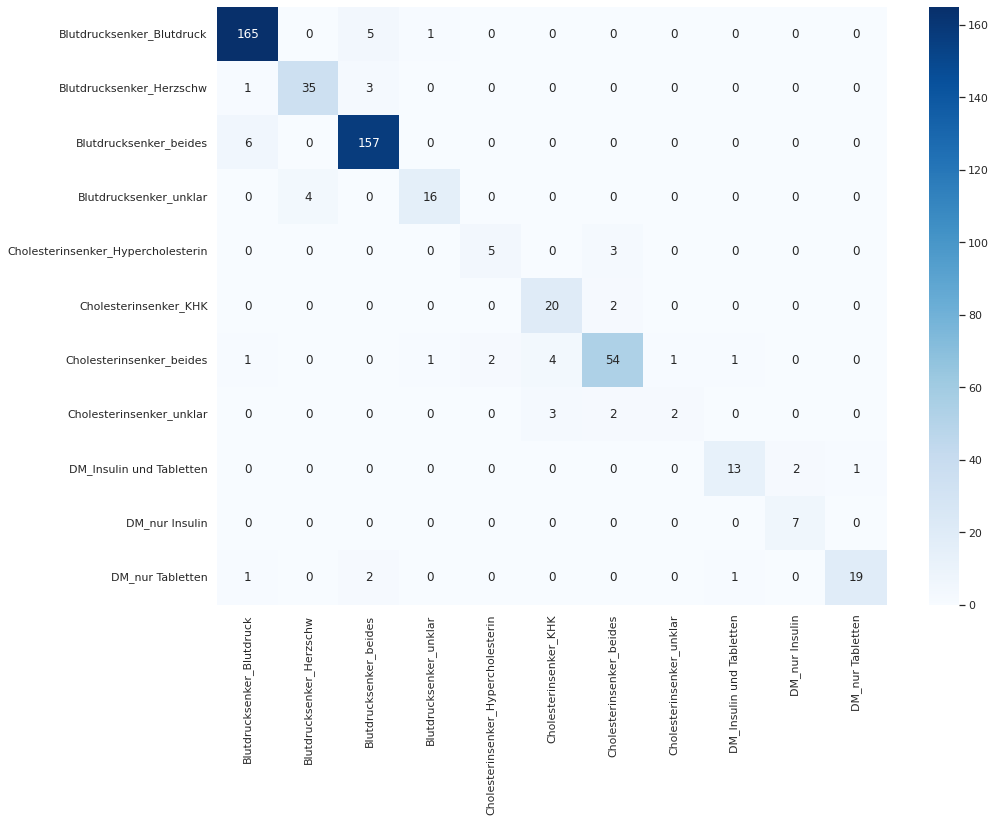

In [102]:
df_cm = pd.DataFrame(metrics["cm"].cpu().numpy(), index = dataset.LE.classes_,
                  columns = dataset.LE.classes_)
df_cm = df_cm.loc[df_cm.index != "Blutdrucksenker_Hypercholesterin", df_cm.columns != "Blutdrucksenker_Hypercholesterin"]
plt.figure(figsize = (15,11))
sns.heatmap(df_cm, annot=True, cmap="Blues", fmt='')